<a href="https://colab.research.google.com/github/Srideep-Kundu/MLProjects/blob/main/LinearRegression(Multiple_Features).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
#importing dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

###Linear Regression Class

In [2]:
class Linear_Regression():

  #initiating the parameters(learning rate and no. of iterations)
  def __init__(self, alpha, epochs):

    self.alpha = alpha
    self.epochs = epochs

  def fit(self, X, Y):
    #no. of training examples and no. of features
    self.m, self.n = X.shape

    #initializing the weights and bias
    self.w = np.zeros(self.n)
    self.b = 0
    self.X = X
    self.Y = Y

    #implementing gradient descent
    for i in range(self.epochs):
      self.update_weights()

  def update_weights(self):
    Y_prediction = self.predict(self.X)

    #calculate gradients
    dw =  (2 * (self.X.T).dot(Y_prediction - self.Y)) / self.m
    db =  2 * np.sum(Y_prediction - self.Y) / self.m

    #update the weights
    self.w = self.w - self.alpha * dw
    self.b = self.b - self.alpha * db

  def predict(self, X):
    return X.dot(self.w) + self.b

###Data Collection and brief analysis

In [5]:
salary = pd.read_csv('/content/salary_data.csv')
salary.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [6]:
salary.shape

(30, 2)

In [7]:
salary.isnull().sum()

,0
YearsExperience,0
Salary,0


In [8]:
salary.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [86]:
X = salary.iloc[:,:-1].values
Y = salary.iloc[:,-1].values

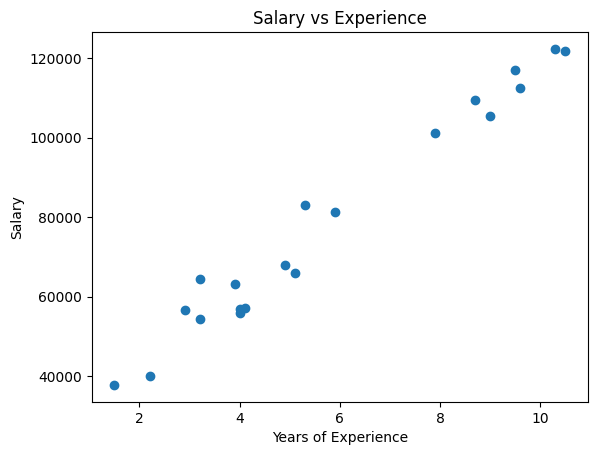

In [87]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.33, random_state = 2)
plt.scatter(X_train, Y_train)
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience')
plt.show()

Implementing Linear Regression

In [88]:
model = Linear_Regression(alpha = 0.01, epochs = 10000)

In [89]:
model.fit(X_train, Y_train)
print('weight = ' , model.w[0])
print('bias = ' , model.b)

weight =  9512.944987627472
bias =  23707.813246574984


In [90]:
X_train_prediction = model.predict(X_train)

In [91]:
X_train_prediction_error = np.mean(np.square(X_train_prediction - Y_train))
print(X_train_prediction_error)

21319426.217045378


In [92]:
X_test_prediction = model.predict(X_test)

In [93]:
X_test_prediction_error = np.mean(np.square(X_test_prediction - Y_test))
print(X_test_prediction_error)

60451409.832682654


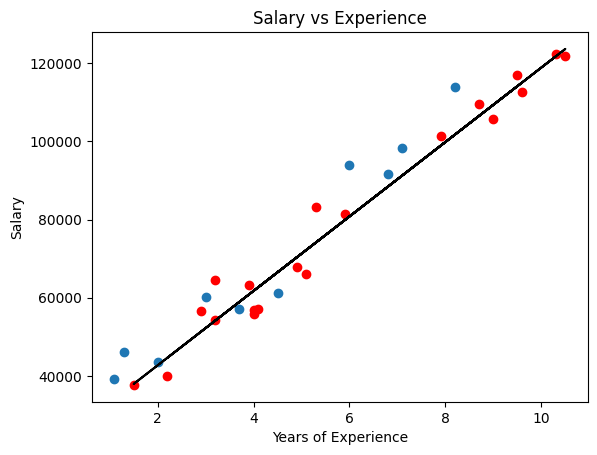

In [99]:
plt.scatter(X_train, Y_train, c='r')
plt.scatter(X_test, Y_test)
plt.plot(X_train, X_train_prediction, color='black')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience')
plt.show()